# 03 - Model Training

This notebook trains the deep autoencoder for anomaly detection.

## Main goals:
1. Load preprocessed data
2. Create PyTorch DataLoaders
3. Initialize the autoencoder model
4. Train on normal data only
5. Monitor training progress

## 0 - Imports and configuration

In [1]:
#Imports
import sys
sys.path.append('../src')

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

#Training functions
from preprocessing import load_preprocessed_data
from train import (
    create_dataloaders,
    initialize_model,
    setup_training,
    train_model,
    plot_training_history
)

#Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

#Random seeds
torch.manual_seed(42)
np.random.seed(42)

## 1 - Load preprocessed data

In [2]:
#Data loading
data = load_preprocessed_data('../data/processed')

X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']

print(f"Train : {X_train.shape}")
print(f"Val :   {X_val.shape}")
print(f"Test :  {X_test.shape}")

input_dim = X_train.shape[1]
print(f"Input dimension : {input_dim}")

Train : (52327, 33)
Val :   (12075, 33)
Test :  (82391, 33)
Input dimension : 33


## 2 - Create DataLoaders

In [3]:
#Configuration
batch_size = 256

#Dataloaders
train_loader, val_loader, test_loader = create_dataloaders(
    X_train, X_val, X_test, 
    batch_size = batch_size
)

DataLoaders created:
Batch size : 256
Train batches : 205
Val batches : 48
Test batches : 322


## 3 - Initialize model

In [4]:
latent_dim = 8

#Model
model, device = initialize_model(
    input_dim = input_dim,
    latent_dim = latent_dim,
    device = None  # Auto-detect
)

Using device: cpu
DeepAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=33, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Linear(in_features=32, out_features=16, bias=True)
    (10): ReLU()
    (11): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_fea

## 4 - Setup training

In [5]:
#Training configuration
learning_rate = 0.001

criterion, optimizer, scheduler = setup_training(
    model,
    learning_rate = learning_rate
)

Training setup:
Optimizer : Adam
Learning rate : 0.001
Loss function : MSE
Scheduler : ReduceLROnPlateau


## 5 - Train the model

In [6]:
#Params
num_epochs = 50
early_stopping_patience = 10
model_save_path = '../models/autoencoder.pth'

#Training
history = train_model(
    model = model,
    train_loader = train_loader,
    val_loader = val_loader,
    criterion = criterion,
    optimizer = optimizer,
    scheduler = scheduler,
    device = device,
    num_epochs = num_epochs,
    early_stopping_patience = early_stopping_patience,
    model_save_path = model_save_path
)

Epoch [  1/50] | Train Loss : 0.326154 | Val Loss : 0.126278
Val Loss: 0.126278


Epoch [  5/50] | Train Loss : 0.078354 | Val Loss : 0.049103
Val Loss: 0.049103


Epoch [ 10/50] | Train Loss : 0.058150 | Val Loss : 0.040116


Epoch [ 15/50] | Train Loss : 0.039713 | Val Loss : 0.028651
Val Loss: 0.028651


Epoch [ 20/50] | Train Loss : 0.037804 | Val Loss : 0.039150


...

Epoch [ 30/50] | Train Loss : 0.033096 | Val Loss : 0.036275


Epoch [ 35/50] | Train Loss : 0.023459 | Val Loss : 0.014820


Epoch [ 40/50] | Train Loss : 0.023897 | Val Loss : 0.013848


Epoch [ 45/50] | Train Loss : 0.022434 | Val Loss : 0.011367
Val Loss: 0.011367


Epoch [ 50/50] | Train Loss : 0.020294 | Val Loss : 0.013438

Validation loss: 0.011367


## 6 - Visualize training history

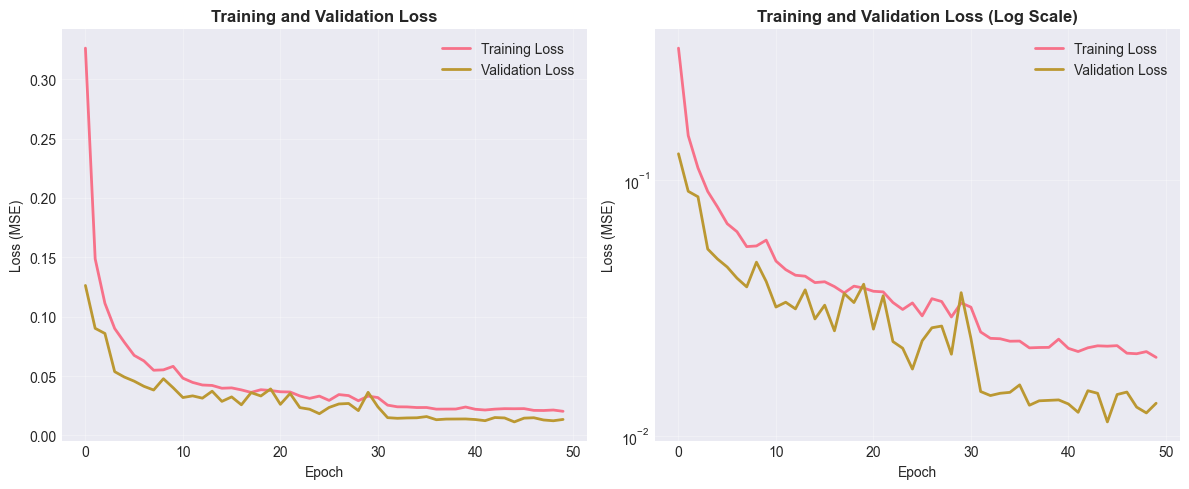

In [7]:
#Plot training history
plot_training_history(
    train_losses = history['train_losses'],
    val_losses = history['val_losses'],
    save_path = '../results/figures/training_history.png'
)

## 7 - Training summary

In [8]:
print("\nConfiguration :")
print(f"Input dimension : {input_dim}")
print(f"Latent dimension : {latent_dim}")
print(f"Batch size : {batch_size}")
print(f"Learning rate : {learning_rate}")
print(f"Device : {device}")

print("\nTraining results :")
print(f"Total epochs : {history['num_epochs']}")
print(f"Val loss : {history['best_val_loss']:.6f}")
print(f"Train loss : {history['train_losses'][-1]:.6f}")
print(f"Val loss : {history['val_losses'][-1]:.6f}")

initial_train = history['train_losses'][0]
final_train = history['train_losses'][-1]
improvement = (initial_train - final_train) / initial_train * 100

print(f"Train loss : {initial_train:.6f} → {final_train:.6f} ({improvement:+.1f}%)")


Configuration :
Input dimension : 33
Latent dimension : 8
Batch size : 256
Learning rate : 0.001
Device : cpu

Training results :
Total epochs : 50
Val loss : 0.011367
Train loss : 0.020294
Val loss : 0.013438
Train loss : 0.326154 → 0.020294 (+93.8%)


## 8 - Calculate reconstruction errors (preview)

In [9]:
from model import get_reconstruction_error

#Model
model.load_state_dict(torch.load(model_save_path, map_location = device))
model.eval()

#Errors
train_errors = get_reconstruction_error(model, train_loader, device)
val_errors = get_reconstruction_error(model, val_loader, device)
test_errors = get_reconstruction_error(model, test_loader, device)

#Label separation
val_normal_errors = val_errors[y_val == 0]
val_attack_errors = val_errors[y_val == 1]
test_normal_errors = test_errors[y_test == 0]
test_attack_errors = test_errors[y_test == 1]

print(f"\nTraining set :")
print(f"Mean error: {train_errors.mean():.6f}")

print(f"\nValidation set :")
print(f"Mean error: {val_normal_errors.mean():.6f}")

print(f"\nTest set:")
print(f"Normal | Mean : {test_normal_errors.mean():.6f}")
print(f"Attack | Mean : {test_attack_errors.mean():.6f}")
print(f"Ratio (Attack/Normal) : {test_attack_errors.mean() / test_normal_errors.mean():.2f}x")


Training set :
Mean error: 0.026712

Validation set :
Mean error: 0.011496

Test set:
Normal | Mean : 0.013145
Attack | Mean : 8.886042
Ratio (Attack/Normal) : 676.00x


## 9 - Visualize reconstruction errors

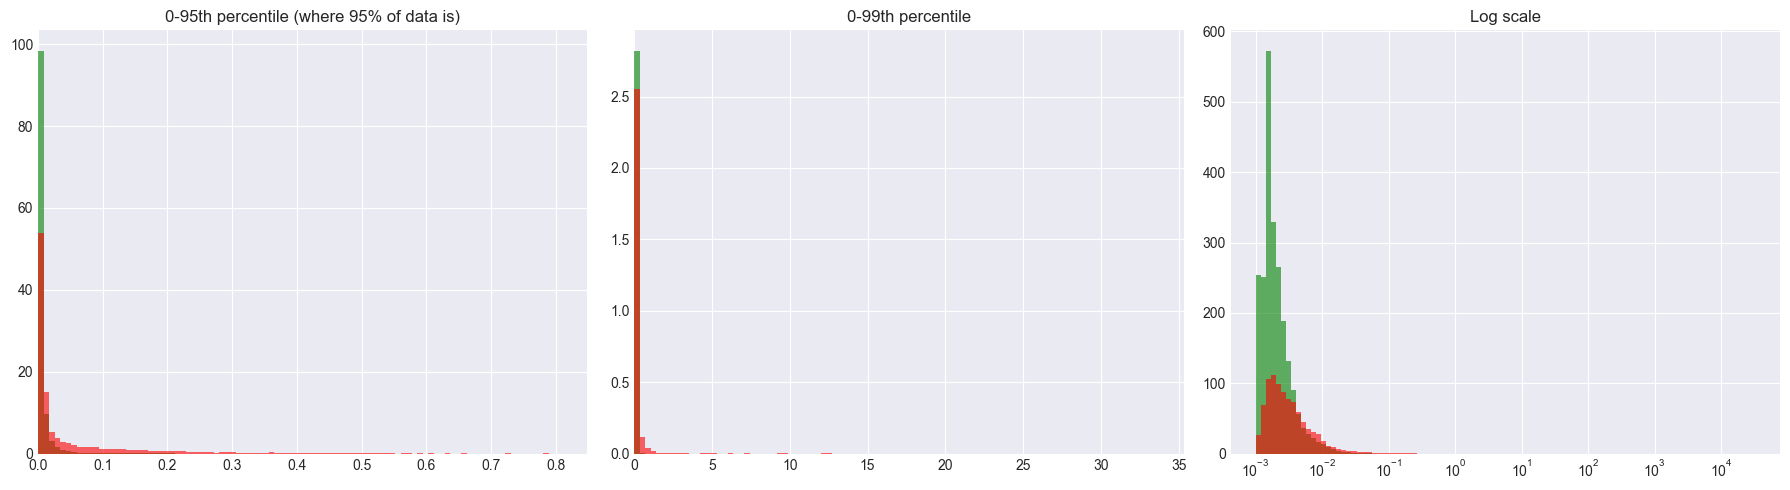

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Zoomed to 95th percentile
xlim_95 = np.percentile(test_errors, 95)
axes[0].hist(test_normal_errors, bins = 100, alpha = 0.6, label = 'Normal', 
            color = 'green', density = True, range = (0, xlim_95))
axes[0].hist(test_attack_errors, bins = 100, alpha = 0.6, label = 'Attack', 
            color = 'red', density = True, range = (0, xlim_95))
axes[0].set_xlim(0, xlim_95)
axes[0].set_title('0-95th percentile (where 95% of data is)')

# 2. Zoomed to 99th percentile
xlim_99 = np.percentile(test_errors, 99)
axes[1].hist(test_normal_errors, bins = 100, alpha = 0.6, label = 'Normal', 
            color = 'green', density = True, range = (0, xlim_99))
axes[1].hist(test_attack_errors, bins = 100, alpha = 0.6, label = 'Attack', 
            color = 'red', density = True, range = (0, xlim_99))
axes[1].set_xlim(0, xlim_99)
axes[1].set_title('0-99th percentile')

# 3. Log scale
bins_log = np.logspace(np.log10(0.001), np.log10(max(test_errors.max(), 1)), 100)
axes[2].hist(test_normal_errors, bins = bins_log, alpha = 0.6, label = 'Normal', 
            color = 'green', density = True)
axes[2].hist(test_attack_errors, bins = bins_log, alpha = 0.6, label = 'Attack', 
            color = 'red', density = True)
axes[2].set_xscale('log')
axes[2].set_title('Log scale')

plt.tight_layout()
plt.savefig('../results/figures/reconstruction_errors_preview.png', dpi = 300, bbox_inches = 'tight')
plt.show()